# 🛍️ Shopping Mall Customer Segmentation
## Member X — Gaussian Mixture Model (GMM)
**Dataset:** Shopping_Mall_Customer_Segmentation_Data_.csv  
**Algorithm:** Gaussian Mixture Model (GMM)  
**Task:** Unsupervised Learning — Customer Segmentation

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Pre-processed Data
> Data was already cleaned and scaled in `step0_eda_preprocessing_no_pca.ipynb`.
> This GMM version uses **scaled features directly** without PCA.


In [2]:
import numpy as np
import pandas as pd


df = pd.read_csv('data/data_preprocessed.csv')
print(f"data loaded, have {df.shape[0]} record")

data loaded, have 15079 record


In [3]:
features_to_use = ['Age', 'Annual Income', 'Spending Score']
X = df[features_to_use]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



## 3. Select Optimal Number of Clusters (BIC)
> GMM does not use bandwidth like MeanShift.  
> Instead, we test different values of **K** and choose the best one using **BIC** (lower is better).


In [4]:
bic_scores = []
aic_scores = []
k_range = range(2, 10)

for k in k_range:
    model = GaussianMixture(
        n_components=k,
        covariance_type='diag',
        random_state=42,
        n_init=5
    )
    model.fit(X_scaled)
    bic_scores.append(model.bic(X_scaled))
    aic_scores.append(model.aic(X_scaled))

best_k = list(k_range)[np.argmin(bic_scores)]
print(f'✅ Best K selected by BIC: {best_k}')

✅ Best K selected by BIC: 9


## 4. BIC / AIC Visualization

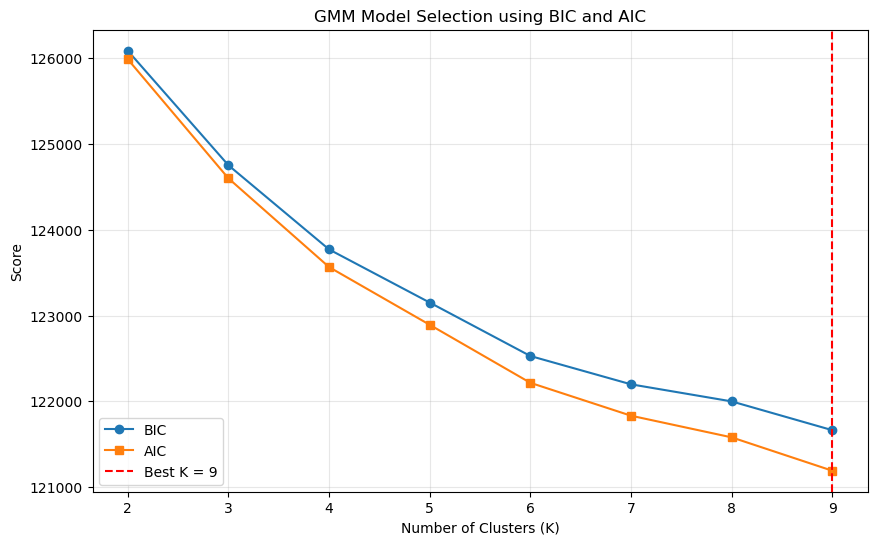

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), bic_scores, marker='o', label='BIC')
plt.plot(list(k_range), aic_scores, marker='s', label='AIC')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')

plt.title('GMM Model Selection using BIC and AIC')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
## Choose k = 8 
best_k = 8

## 5. Train GMM Model
> Train the final Gaussian Mixture Model using the selected number of clusters.


In [7]:
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='diag',
    random_state=42,
    n_init=5
)
gmm.fit(X_scaled)

cluster_labels = gmm.predict(X_scaled)
cluster_probs = gmm.predict_proba(X_scaled)

df['Cluster'] = cluster_labels
n_clusters = len(np.unique(cluster_labels))

print(f'Number of clusters found by GMM: {n_clusters}')
print('\nCluster Distribution:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, cnt in zip(unique, counts):
    print(f'  Cluster {c}: {cnt} customers ({cnt/len(df)*100:.1f}%)')

Number of clusters found by GMM: 8

Cluster Distribution:
  Cluster 0: 1959 customers (13.0%)
  Cluster 1: 1786 customers (11.8%)
  Cluster 2: 1971 customers (13.1%)
  Cluster 3: 2027 customers (13.4%)
  Cluster 4: 1794 customers (11.9%)
  Cluster 5: 1777 customers (11.8%)
  Cluster 6: 1968 customers (13.1%)
  Cluster 7: 1797 customers (11.9%)


## 6. Evaluation Metrics

In [8]:
import pandas as pd
import pickle
# Evaluation metrics
sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)

print('=' * 72)
print('                GMM EVALUATION METRICS')
print('=' * 72)
print(f'  Algorithm                 : Gaussian Mixture Model (GMM)')
print(f'  Best K Selected           : {best_k}')
print(f'  Input Feature Space       : X_scaled')
print(f'  Silhouette Score          : {sil:.4f}  (higher = better)')
print(f'  Davies-Bouldin Index      : {dbi:.4f}  (lower = better)')
print(f'  Final BIC Score           : {gmm.bic(X_scaled):.2f}')
print(f'  Final AIC Score           : {gmm.aic(X_scaled):.2f}')
print(f'  Noise Points              : 0')
print('=' * 72)


decision_df = pd.DataFrame([
    {
        'Pipeline': 'Final: GMM on X_scaled',
        'K': best_k,
        'Silhouette': round(sil, 4),
        'Davies-Bouldin': round(dbi, 4),
        'BIC': round(gmm.bic(X_scaled), 2),
        'AIC': round(gmm.aic(X_scaled), 2),
        'Noise': 0
    }
])

print('\n=== Final decision support ===')
print(decision_df.to_string(index=False))

# User explanation
print('\n📌 User-facing explanation:')
print('   1. GMM models data as a mixture of Gaussian distributions.')
print('   2. Each customer is assigned probabilistically to clusters.')
print('   3. BIC and AIC are used to determine the optimal number of clusters.')
print('   4. Silhouette and Davies-Bouldin evaluate cluster separation and compactness.')
print('   5. GMM does not produce noise points; all data points are assigned to clusters.')

# Save scores
scores = {
    'algorithm': 'GMM',
    'n_clusters': int(best_k),
    'silhouette': round(float(sil), 4),
    'davies_bouldin': round(float(dbi), 4),
    'bic': round(float(gmm.bic(X_scaled)), 2),
    'aic': round(float(gmm.aic(X_scaled)), 2),
    'noise': 0
}

pickle.dump(scores, open('data/gmm_scores.pkl', 'wb'))
pickle.dump(cluster_labels, open('data/gmm_labels.pkl', 'wb'))

print('\nGMM scores saved.')

                GMM EVALUATION METRICS
  Algorithm                 : Gaussian Mixture Model (GMM)
  Best K Selected           : 8
  Input Feature Space       : X_scaled
  Silhouette Score          : 0.2796  (higher = better)
  Davies-Bouldin Index      : 0.9777  (lower = better)
  Final BIC Score           : 121999.12
  Final AIC Score           : 121579.96
  Noise Points              : 0

=== Final decision support ===
              Pipeline  K  Silhouette  Davies-Bouldin       BIC       AIC  Noise
Final: GMM on X_scaled  8      0.2796          0.9777 121999.12 121579.96      0

📌 User-facing explanation:
   1. GMM models data as a mixture of Gaussian distributions.
   2. Each customer is assigned probabilistically to clusters.
   3. BIC and AIC are used to determine the optimal number of clusters.
   4. Silhouette and Davies-Bouldin evaluate cluster separation and compactness.
   5. GMM does not produce noise points; all data points are assigned to clusters.

GMM scores saved.


## 7. Cluster Visualization (Original Feature Space)
> Since PCA is not used, we visualise the clustering result directly in the original scaled feature space.


In [9]:
feature_cols = ['Annual Income', 'Spending Score', 'Age']
# 🔥 把 df_clean 改成 df
X_vis = df[feature_cols].values

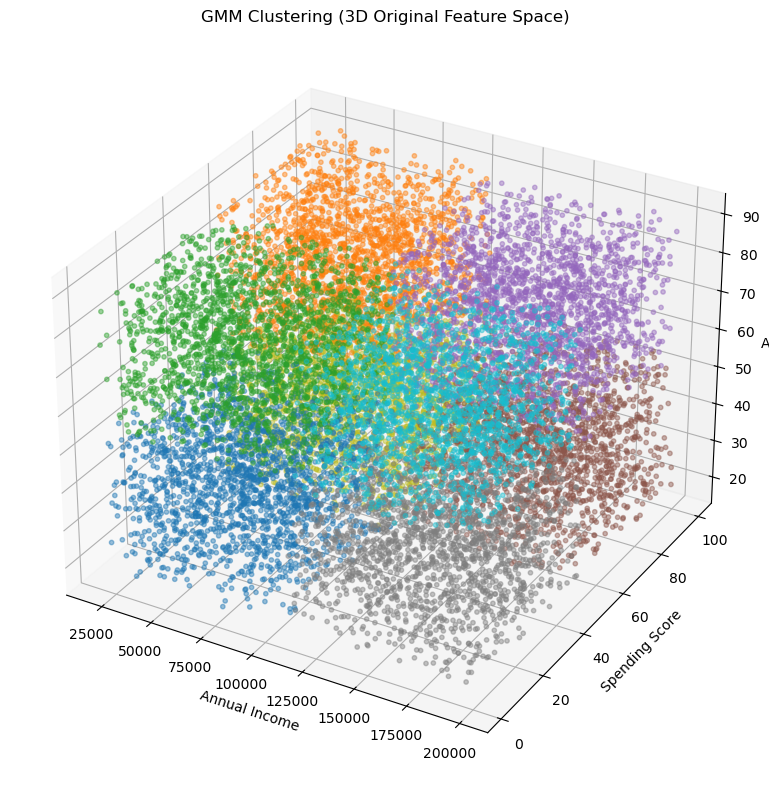

In [10]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Annual Income'],
    df['Spending Score'],
    df['Age'],
    c=cluster_labels,
    cmap='tab10',
    s=10,
    alpha=0.45
)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title('GMM Clustering (3D Original Feature Space)')
plt.tight_layout()
plt.show()

## 8. Cluster Profile Analysis

In [11]:
profile = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean().round(2)
profile['Count'] = df.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(2)
print('Cluster Profiles:')
profile

Cluster Profiles:


,Age,Annual Income,Spending Score,Count,% of Total
Cluster,,,,,
0,36.46,63793.62,26.36,1959,12.99
1,72.11,62406.10,76.14,1786,11.84
2,72.81,67501.35,25.51,1971,13.07
3,72.67,152830.41,73.78,2027,13.44
4,35.76,157478.82,76.14,1794,11.90
5,34.98,156076.02,25.19,1777,11.78
6,35.98,67221.36,75.26,1968,13.05
7,71.80,157704.92,25.58,1797,11.92


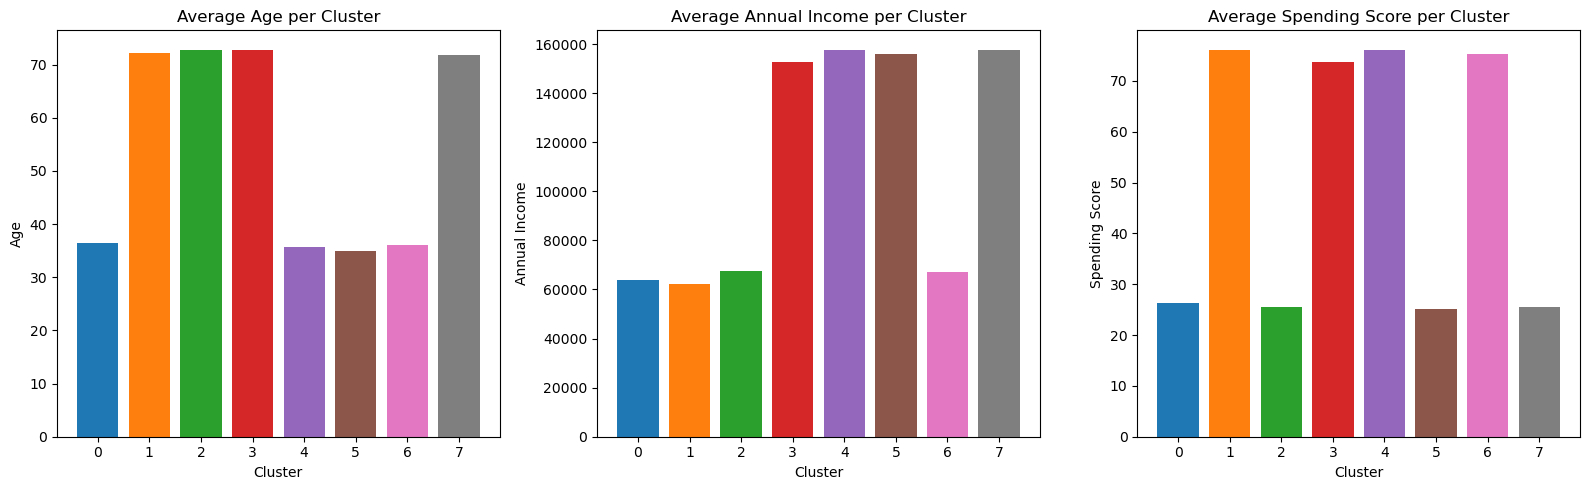

In [12]:
# Bar chart of cluster averages
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
features = ['Age', 'Annual Income', 'Spending Score']
palette_bar = sns.color_palette('tab10', n_clusters)

for i, feat in enumerate(features):
    cluster_means = df.groupby('Cluster')[feat].mean()
    axes[i].bar(cluster_means.index.astype(str), cluster_means.values, color=palette_bar)
    axes[i].set_title(f'Average {feat} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.savefig('gmm_cluster_profiles.png', dpi=150)
plt.show()

## 9. Membership Probability Analysis

In [13]:
prob_df = pd.DataFrame(cluster_probs, columns=[f'Prob_Cluster_{i}' for i in range(n_clusters)])
prob_df['Predicted_Cluster'] = cluster_labels

print('First 10 customers with cluster membership probabilities:')
prob_df.head(10)

First 10 customers with cluster membership probabilities:


,Prob_Cluster_0,Prob_Cluster_1,Prob_Cluster_2,Prob_Cluster_3,Prob_Cluster_4,Prob_Cluster_5,Prob_Cluster_6,Prob_Cluster_7,Predicted_Cluster
0,1.074620e-05,2.302600e-05,7.408910e-09,1.153643e-03,9.825565e-01,5.873181e-04,0.015666,2.327269e-06,4
1,2.944118e-08,1.729173e-04,6.352022e-08,6.807601e-01,3.185973e-01,4.903245e-05,0.000186,2.349209e-04,3
2,1.368791e-03,8.579201e-01,5.141636e-03,1.777917e-02,9.493341e-04,8.405969e-06,0.116766,6.649717e-05,1
3,2.594584e-01,3.502003e-04,2.493931e-05,7.311440e-07,9.350212e-04,5.345379e-04,0.738696,1.800561e-07,6
4,8.021679e-05,4.095360e-06,1.431766e-08,2.356220e-04,9.800026e-01,7.148371e-03,0.012523,6.335659e-06,4
5,4.401221e-03,2.178188e-05,2.467412e-04,5.654992e-03,1.044922e-01,8.313590e-01,0.001260,5.256385e-02,5
6,2.395433e-03,1.751580e-07,2.117946e-06,5.611282e-05,6.099197e-02,9.346280e-01,0.000446,1.480192e-03,5
7,9.832999e-01,7.483870e-07,1.883318e-04,1.644970e-08,9.800134e-06,1.371219e-02,0.002783,6.218471e-06,0
8,5.342101e-04,3.131755e-02,9.675046e-01,1.315958e-04,9.774310e-09,2.855827e-07,0.000033,4.783732e-04,2
9,1.192825e-01,6.215590e-05,8.768335e-01,2.386053e-06,2.798453e-08,5.458548e-04,0.000029,3.244097e-03,2


## 10. Summary

In [14]:
print('=' * 55)
print('         GMM CLUSTERING — FINAL SUMMARY')
print('=' * 55)
print(f'  Algorithm             : Gaussian Mixture Model (GMM)')
print(f'  Best K Selected       : {best_k}')
print(f'  Covariance Type       : diag')
print(f'  Total Customers       : {len(df)}')
print(f'  Silhouette Score      : {sil:.4f}')
print(f'  Davies-Bouldin Index  : {dbi:.4f}')
print(f'  Final BIC Score       : {gmm.bic(X_scaled):.2f}')
print('=' * 55)
print('\nKey advantage of GMM:')
print('  - Provides soft clustering using membership probabilities')
print('  - Can model overlapping clusters better than K-Means')


         GMM CLUSTERING — FINAL SUMMARY
  Algorithm             : Gaussian Mixture Model (GMM)
  Best K Selected       : 8
  Covariance Type       : diag
  Total Customers       : 15079
  Silhouette Score      : 0.2796
  Davies-Bouldin Index  : 0.9777
  Final BIC Score       : 121999.12

Key advantage of GMM:
  - Provides soft clustering using membership probabilities
  - Can model overlapping clusters better than K-Means


          CUSTOMER CLUSTER PROFILES
               Age  Annual Income  Spending Score
Cluster                                          
0        36.457887   63793.621746       26.361919
1        72.106943   62406.100224       76.138298
2        72.811263   67501.353628       25.507357
3        72.671929  152830.411445       73.776024
4        35.758082  157478.824972       76.139911
5        34.976927  156076.016320       25.187957
6        35.975610   67221.363821       75.259654
7        71.803005  157704.923205       25.576516

Number of customers in each cluster:
Cluster
3    2027
2    1971
6    1968
0    1959
7    1797
4    1794
1    1786
5    1777
Name: count, dtype: int64


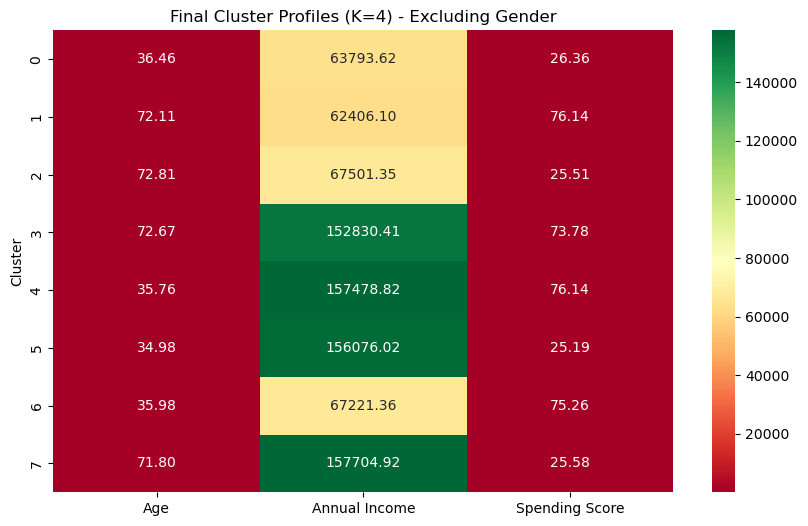

In [15]:
cluster_profiles = df.groupby('Cluster').mean(numeric_only=True)

print("=============================================")
print("          CUSTOMER CLUSTER PROFILES")
print("=============================================")
print(cluster_profiles)
print("=============================================")

print("\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

plot_features = ['Age', 'Annual Income', 'Spending Score']
display_profiles = df.groupby('Cluster')[plot_features].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(display_profiles, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Final Cluster Profiles (K=4) - Excluding Gender')
plt.show()

---
# 🔮 Predict Customer Segment
> Enter a new customer's details below and the trained model will predict which segment they belong to.


In [ ]:
# ============================================================
#  ENTER CUSTOMER DETAILS HERE
# ============================================================
input_age            = int(input('Enter Age            : '))
input_annual_income  = float(input('Enter Annual Income : '))
input_spending_score = float(input('Enter Spending Score (1-100): '))

# 1. [Age, Annual Income, Spending Score]

new_customer_features = [[input_age, input_annual_income, input_spending_score]]

# 2. scaler
new_customer_scaled = scaler.transform(new_customer_features)

# 3. GMM
predicted_cluster = gmm.predict(new_customer_scaled)[0]
membership_probs  = gmm.predict_proba(new_customer_scaled)[0]

# 4. cluster draw
cluster_profile = df[df['Cluster'] == predicted_cluster][['Age', 'Annual Income', 'Spending Score']].mean()
cluster_size = (df['Cluster'] == predicted_cluster).sum()

# ============================================================
#  OUTPUT RESULTS
# ============================================================
print()
print('=' * 55)
print('             GMM — PREDICTION RESULT')
print('=' * 55)
print(f'  Input  → Age: {input_age}')
print(f'           Annual Income: {input_annual_income:,.0f}')
print(f'           Spending Score: {input_spending_score:.1f}')
print()
print(f'   Predicted Cluster : {predicted_cluster}')
print(f'   Cluster Size      : {cluster_size} customers')
print()
print('  Cluster Membership Probabilities:')
for i, prob in enumerate(membership_probs):
    marker = ' <-- (Current Assignment)' if i == predicted_cluster else ''
    print(f'    Cluster {i}: {prob:.4f}{marker}')
print()
print('  Cluster Average Profile:')
print(f'    Average Age           : {cluster_profile["Age"]:.1f}')
print(f'    Average Annual Income : {cluster_profile["Annual Income"]:,.0f}')
print(f'    Average Spending Score: {cluster_profile["Spending Score"]:.1f}')
print('=' * 55)

In [ ]:
cluster_data = df[df['Cluster'] == predicted_cluster][['Age', 'Annual Income', 'Spending Score']]

print("\n  Cluster Range:")
print(f"    Age Range           : {cluster_data['Age'].min()} - {cluster_data['Age'].max()}")
print(f"    Annual Income Range : {cluster_data['Annual Income'].min():,.0f} - {cluster_data['Annual Income'].max():,.0f}")
print(f"    Spending Score Range: {cluster_data['Spending Score'].min():.0f} - {cluster_data['Spending Score'].max():.0f}")

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# ============================================================
#  3D INTERACTIVE PLOT (No PCA needed since we have exactly 3 features!)
# ============================================================

# 1. variable
df_plot = df[['Age', 'Annual Income', 'Spending Score']].copy()
df_plot['Cluster'] = cluster_labels.astype(str)

# 2. 3D 
fig = px.scatter_3d(
    df_plot,
    x='Annual Income',       # X income
    y='Spending Score',      # Y spending score
    z='Age',                 # Z age
    color='Cluster',
    opacity=0.35,            
    title='GMM Clustering — New Customer Prediction',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# 3. Star
fig.add_trace(go.Scatter3d(
    x=[input_annual_income],
    y=[input_spending_score],
    z=[input_age],
    mode='markers+text',
    text=[f' YOU (Cluster {predicted_cluster})'], 
    textposition='top center',
    textfont=dict(size=12, color='black', weight='bold'),
    marker=dict(size=12, color='red', symbol='diamond', line=dict(color='black', width=2)),
    name=f'New Customer -> Cluster {predicted_cluster}'
))

# 4. camera angle
fig.update_layout(
    scene=dict(
        xaxis_title='Annual Income ($)',
        yaxis_title='Spending Score (1-100)',
        zaxis_title='Age',
        camera=dict(
            up=dict(x=0, y=0, z=1),
            center=dict(x=0, y=0, z=0),
            eye=dict(x=0, y=-2.0, z=0.1) 
        )
    ),
    legend_title_text='Cluster',
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()